In [1]:
import ast
import concurrent.futures
import glob
import itertools
import os
import pickle
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

import dask
import dask.dataframe as dd
import dask_ml.cluster as dask_cluster
from dask.distributed import Client
from dask.diagnostics import ProgressBar

from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count

from sklearn.linear_model import LinearRegression
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
#from sklearn.cluster import KMeans

from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm
from collections import Counter
from functools import reduce
from pprint import pprint

pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Generate/Load Merged Results

In [2]:
### Params
REUSE_RESULTS = True
K_list = list(range(1,21)) + list(range(100,3200,100)) + [3136]
#K_list = [1800]
### Directory to save/load merged best windows from
merged_directory = "./merged_kmeans_tcv_validation"
os.makedirs(merged_directory, exist_ok=True)
### Load in the datasets
kmeans_tcv_validation_directory = "./kmeans_tcv_validation"
concatenated_dfs = {}
for K in tqdm(K_list):
    K_subfolder = os.path.join(kmeans_tcv_validation_directory,str(K))
    
    concatenated_df_fname = "merged_K={}.csv".format(K)
    concatenated_df_fpath = os.path.join(merged_directory, concatenated_df_fname)
    # Load file if exists, otherwise, create it and save it
    if os.path.exists(os.path.join(concatenated_df_fpath)) and REUSE_RESULTS:
        concatenated_dfs[K] = pd.read_csv(concatenated_df_fpath)
        
    else:
        print("K={} does not exist! Creating".format(K))
        
        file_names = os.listdir(K_subfolder)
        file_paths = [os.path.join(K_subfolder, file_name) for file_name in file_names]
        dfs = [dd.read_csv(file, assume_missing=True) for file in file_paths]
        concatenated_df = dd.concat(dfs).compute()
        concatenated_df = concatenated_df.sort_values(by=["date", "k"])
        concatenated_df.to_csv(concatenated_df_fpath, index=False)
        concatenated_dfs[K] = concatenated_df

    concatenated_dfs[K]["date"] = pd.to_datetime(concatenated_dfs[K]["date"])
    concatenated_dfs[K]["date_query"] = concatenated_dfs[K]["date"] + pd.Timedelta(days=7)
    concatenated_dfs[K] = concatenated_dfs[K].drop(columns=["date"])

### Load in Cluster Data

In [3]:
kmeans_clusters_by_fips = pd.read_csv("kmeans_clusters_by_fips.csv")
kmeans_clusters_by_fips

,fips,kmeans_k=1_labels,kmeans_k=2_labels,kmeans_k=3_labels,kmeans_k=4_labels,kmeans_k=5_labels,kmeans_k=6_labels,kmeans_k=7_labels,kmeans_k=8_labels,kmeans_k=9_labels,kmeans_k=10_labels,kmeans_k=11_labels,kmeans_k=12_labels,kmeans_k=13_labels,kmeans_k=14_labels,kmeans_k=15_labels,kmeans_k=16_labels,kmeans_k=17_labels,kmeans_k=18_labels,kmeans_k=19_labels,kmeans_k=20_labels,kmeans_k=100_labels,kmeans_k=200_labels,kmeans_k=300_labels,kmeans_k=400_labels,kmeans_k=500_labels,kmeans_k=600_labels,kmeans_k=700_labels,kmeans_k=800_labels,kmeans_k=900_labels,kmeans_k=1000_labels,kmeans_k=1100_labels,kmeans_k=1200_labels,kmeans_k=1300_labels,kmeans_k=1400_labels,kmeans_k=1500_labels,kmeans_k=1600_labels,kmeans_k=1700_labels,kmeans_k=1800_labels,kmeans_k=1900_labels,kmeans_k=2000_labels,kmeans_k=2100_labels,kmeans_k=2200_labels,kmeans_k=2300_labels,kmeans_k=2400_labels,kmeans_k=2500_labels,kmeans_k=2600_labels,kmeans_k=2700_labels,kmeans_k=2800_labels,kmeans_k=2900_labels,kmeans_k=3000_labels,kmeans_k=3100_labels,kmeans_k=3136_labels
0,1001,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,22,152,51,306,28,28,28,28,28,28,704,1197,1197,1197,1197,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1121,1121,0
1,1003,0,0,0,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,43,169,24,24,419,419,419,419,419,419,372,372,372,372,372,372,372,372,372,372,372,372,372,372,372,372,372,372,372,488,488,1
2,1005,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,8,141,141,344,65,482,65,65,65,979,803,803,803,803,803,1587,1587,1763,1763,1763,1763,1763,1763,1763,1763,1763,1763,1763,1763,1063,1063,2
3,1007,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,8,9,9,344,65,65,65,65,65,65,226,1104,1104,1104,1104,1104,1104,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1362,1362,3
4,1009,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,46,9,267,339,9,9,657,649,649,649,312,312,312,312,312,312,312,312,312,312,312,312,312,312,312,312,312,312,312,1575,1575,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3131,56039,0,0,0,0,4,4,4,7,7,7,7,7,7,7,7,7,7,7,7,7,38,111,111,393,279,279,279,279,279,279,482,482,482,482,482,482,482,482,482,482,482,482,482,482,482,482,482,482,482,434,434,3131
3132,56041,0,0,0,0,4,4,4,7,7,7,7,7,7,7,7,7,7,7,7,7,10,166,166,304,234,234,234,234,234,234,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,275,275,3132
3133,56043,0,0,0,0,4,4,4,7,7,7,7,7,7,7,7,7,7,7,7,7,10,166,166,304,234,234,234,473,473,473,5,5,5,5,5,5,1675,1675,1675,1675,1675,1675,1675,1675,1675,1675,1675,2748,2748,2756,2756,3133
3134,56045,0,0,0,0,4,4,4,7,7,7,7,7,7,7,7,7,7,7,7,7,10,166,166,304,473,473,473,473,473,473,754,754,754,754,754,754,754,754,754,754,2043,2043,2043,2043,2043,2043,2043,2043,2043,949,949,3134


### Load in Diffs

In [4]:
all_beta_df_results_diff = dd.read_csv("Fixed_Windows_Validation_Diff.csv", assume_missing=True).compute()
all_beta_df_results_diff["date"] = pd.to_datetime(all_beta_df_results_diff["date"])
all_beta_df_results_diff = all_beta_df_results_diff.sort_values(by=["fips", "date"])

pattern = r'diff_wsize=\d+_shift=7'
filtered_cols = all_beta_df_results_diff.filter(regex=pattern).columns

# Include the filtered columns and desired non-matching columns
desired_cols = ['fips','date', 'days_from_start'] + list(filtered_cols)

all_beta_df_results_diff_test = all_beta_df_results_diff[desired_cols]
all_beta_df_results_diff_test["date"] = pd.to_datetime(all_beta_df_results_diff_test["date"])
all_beta_df_results_diff_test

/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


,fips,date,days_from_start,diff_wsize=2_shift=7,diff_wsize=3_shift=7,diff_wsize=4_shift=7,diff_wsize=5_shift=7,diff_wsize=6_shift=7,diff_wsize=7_shift=7,diff_wsize=8_shift=7,diff_wsize=9_shift=7,diff_wsize=10_shift=7,diff_wsize=11_shift=7,diff_wsize=12_shift=7,diff_wsize=13_shift=7,diff_wsize=14_shift=7
0,1001.0,2020-03-30,69.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1001.0,2020-03-31,70.0,0.332681,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1001.0,2020-04-01,71.0,0.321336,0.372722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1001.0,2020-04-02,72.0,0.003182,0.159363,0.252667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1001.0,2020-04-03,73.0,0.233440,0.140987,0.197715,0.262252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6888,99999.0,2023-03-19,1153.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6889,99999.0,2023-03-20,1154.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6890,99999.0,2023-03-21,1155.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6891,99999.0,2023-03-22,1156.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Obtain `fips_list` given cluster `Kk`

In [5]:
def generate_mask(df=kmeans_clusters_by_fips, K=1, k=0):
    assert isinstance(K, int) and 1 <= K <= 3136, "K must be an integer $\in$ [1,3136]"
    assert isinstance(k, int) and 0 <= k < K, "k must be an integer $\in$ [0,k)"
    fips_list = df[df["kmeans_k={}_labels".format(K)] == k]["fips"].values
    
    return fips_list

### Set `date_query` to be 7 days after validation end

In [78]:
###
REUSE_MERGED = True

query_dfs = {}
generation_cols_to_convert = ["K","k", "best_mae_window", "best_rmse_window", "fips"]
loading_cols_to_convert = ["K", "k", "fips"]


tcv_kmeans_query_dfs_directory = "./kmeans_tcv_query_dfs"
os.makedirs(tcv_kmeans_query_dfs_directory, exist_ok=True)



for K in tqdm(K_list):
    query_df_fname = "query_K={}.csv".format(K)
    query_df_path = os.path.join(tcv_kmeans_query_dfs_directory, query_df_fname)
    if os.path.exists(os.path.join(query_df_path)) and REUSE_MERGED:
        query_dfs[K] = pd.read_csv(query_df_path)
        query_dfs[K][loading_cols_to_convert] = query_dfs[K][loading_cols_to_convert].astype(np.int64)
        query_dfs[K]["date_query"] = pd.to_datetime(query_dfs[K]["date_query"])

    else:
        print("K={} does not exist! Generating".format(K))
        K_fips = kmeans_clusters_by_fips[["fips","kmeans_k={}_labels".format(K)]]
        query_dfs[K] = pd.merge(concatenated_dfs[K], K_fips, left_on="k", right_on="kmeans_k={}_labels".format(K), how="left")
        query_dfs[K] = query_dfs[K].sort_values(by=["date_query", "k", "fips"])


        query_dfs[K][generation_cols_to_convert] = query_dfs[K][generation_cols_to_convert].astype(np.int64)

        query_dfs[K]["mae_diff_name"] = query_dfs[K]['best_mae_window'].apply(lambda x: "diff_wsize={}_shift=7".format(x))
        query_dfs[K]["rmse_diff_name"] = query_dfs[K]['best_rmse_window'].apply(lambda x: "diff_wsize={}_shift=7".format(x))
        query_dfs[K] = query_dfs[K].drop(columns=["kmeans_k={}_labels".format(K) , "best_mae_window", "best_rmse_window"])
        query_dfs[K].to_csv(query_df_path, index=False)

### Merge with `all_beta_df_results_diff_test`

In [81]:
daily_metrics_dfs = {}
#for K in tqdm(K_list):
daily_metrics_dfs_directory = "./daily_metrics_dfs"
os.makedirs(daily_metrics_dfs_directory, exist_ok=True)
for K in tqdm(K_list):
    daily_metrics_fname = "daily_metrics_K={}.csv".format(K)
    daily_metrics_path = os.path.join(daily_metrics_dfs_directory, daily_metrics_fname)
    
    if os.path.exists(daily_metrics_path):
        daily_metrics_df = pd.read_csv(daily_metrics_path)
        daily_metrics_df["date_query"] = pd.to_datetime(daily_metrics_df["date_query"])
        daily_metrics_df.set_index('date_query', inplace=True)
        #daily_metrics_df.drop(columns='date_query', inplace=True)
    
    else:
        print("K={} does not exist! Creating...".format(K))
    
        query_diff_df = pd.merge(query_dfs[K], all_beta_df_results_diff_test, left_on=['date_query','fips'], right_on=['date','fips'])

        daily_metrics_df = pd.DataFrame()


        for val in ["mae", "rmse"]:
            dk_grouped = query_diff_df.groupby(["date_query","k"]).apply(lambda x : x[x["{}_diff_name".format(val)].unique()[0]].values)
            dk_grouped = pd.DataFrame(dk_grouped).rename(columns={0:"diffs"})
            dk_grouped_merged = dk_grouped.groupby('date_query')['diffs'].apply(lambda x: np.concatenate(x))

            for metric in ["MAE", "RMSE"]:
                cname = "Chosen_by_{}_{}".format(val, metric)
                if metric == "MAE":
                    daily_metrics_df[cname] = dk_grouped_merged.apply(lambda x : np.nanmean(np.abs(x)))
                else:
                    daily_metrics_df[cname] = dk_grouped_merged.apply(lambda x : np.sqrt(np.nanmean(np.square(x))))
        
        daily_metrics_df.to_csv(daily_metrics_path)
    daily_metrics_dfs[K] = daily_metrics_df

In [86]:
col_names = ["K"] + list(daily_metrics_dfs[1].columns)
medians_df = pd.DataFrame(columns=col_names)
for K in K_list:
    row = [K] + list(daily_metrics_dfs[K].median())
    medians_df = medians_df.append(pd.Series(row, index=medians_df.columns), ignore_index=True)


In [87]:
medians_df

,K,Chosen_by_mae_MAE,Chosen_by_mae_RMSE,Chosen_by_rmse_MAE,Chosen_by_rmse_RMSE
0,1.0,0.175218,0.337424,0.179259,0.337693
1,2.0,0.174714,0.332774,0.178687,0.334926
2,3.0,0.174694,0.332853,0.178453,0.335209
3,4.0,0.174097,0.332251,0.178111,0.334987
4,5.0,0.174694,0.334711,0.178561,0.337210
5,6.0,0.175004,0.335534,0.178566,0.336366
6,7.0,0.175004,0.332274,0.178425,0.335462
7,8.0,0.174813,0.333842,0.178196,0.335430
8,9.0,0.174814,0.333842,0.178197,0.335434
9,10.0,0.174774,0.333344,0.178082,0.335183


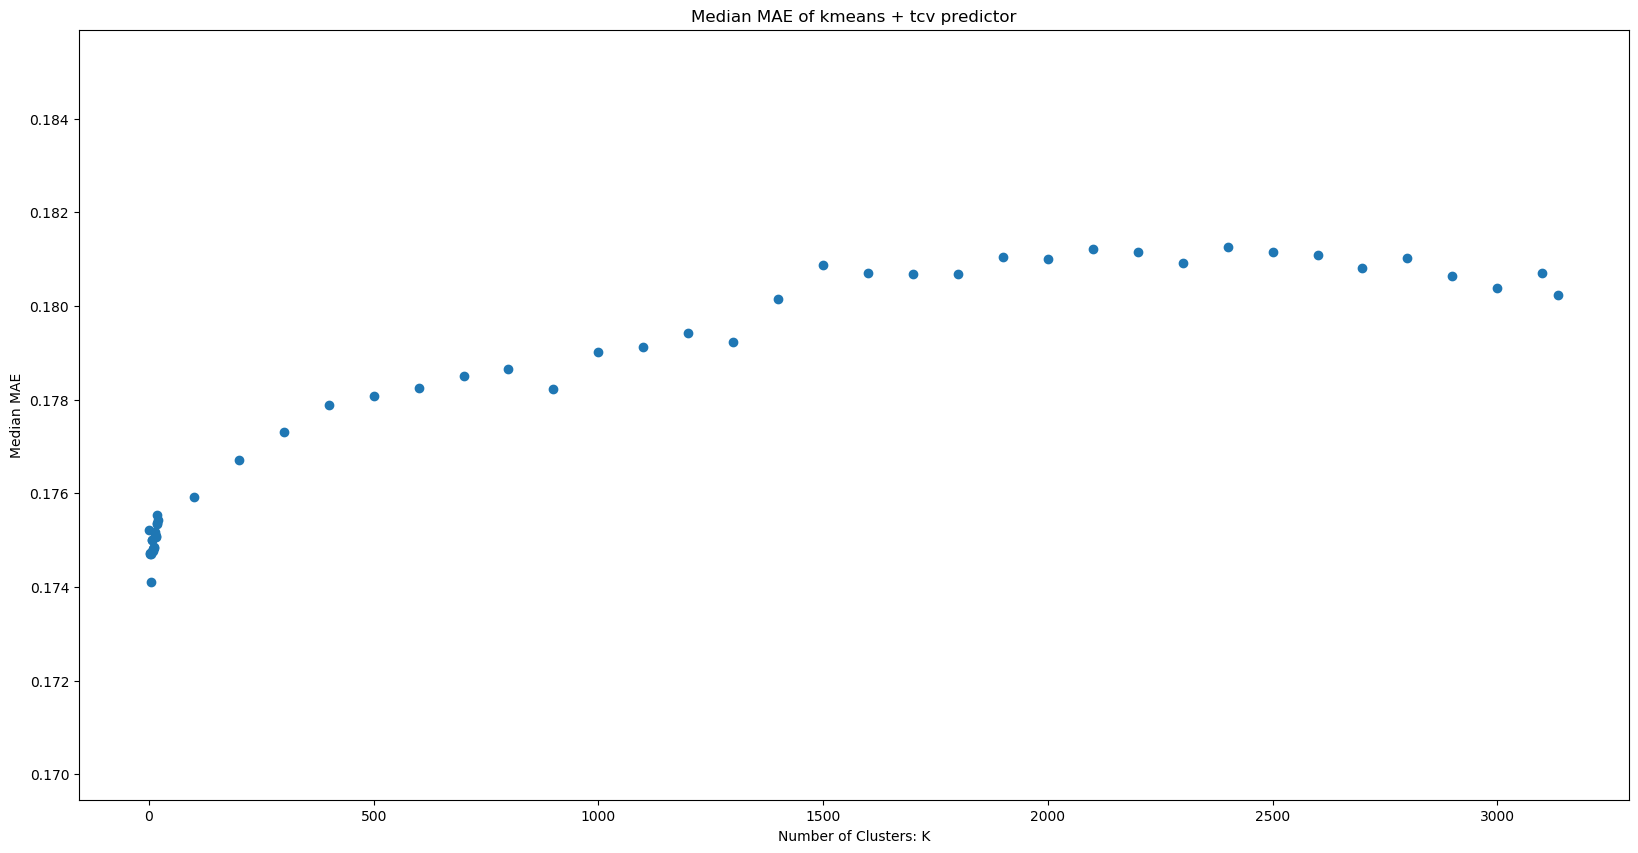

In [92]:
plt.figure(figsize=(20,10))
plt.scatter(medians_df["K"], medians_df["Chosen_by_mae_MAE"])
plt.xlabel("Number of Clusters: K")
plt.ylabel("Median MAE")
plt.title("Median MAE of kmeans + tcv predictor")
plt.show()

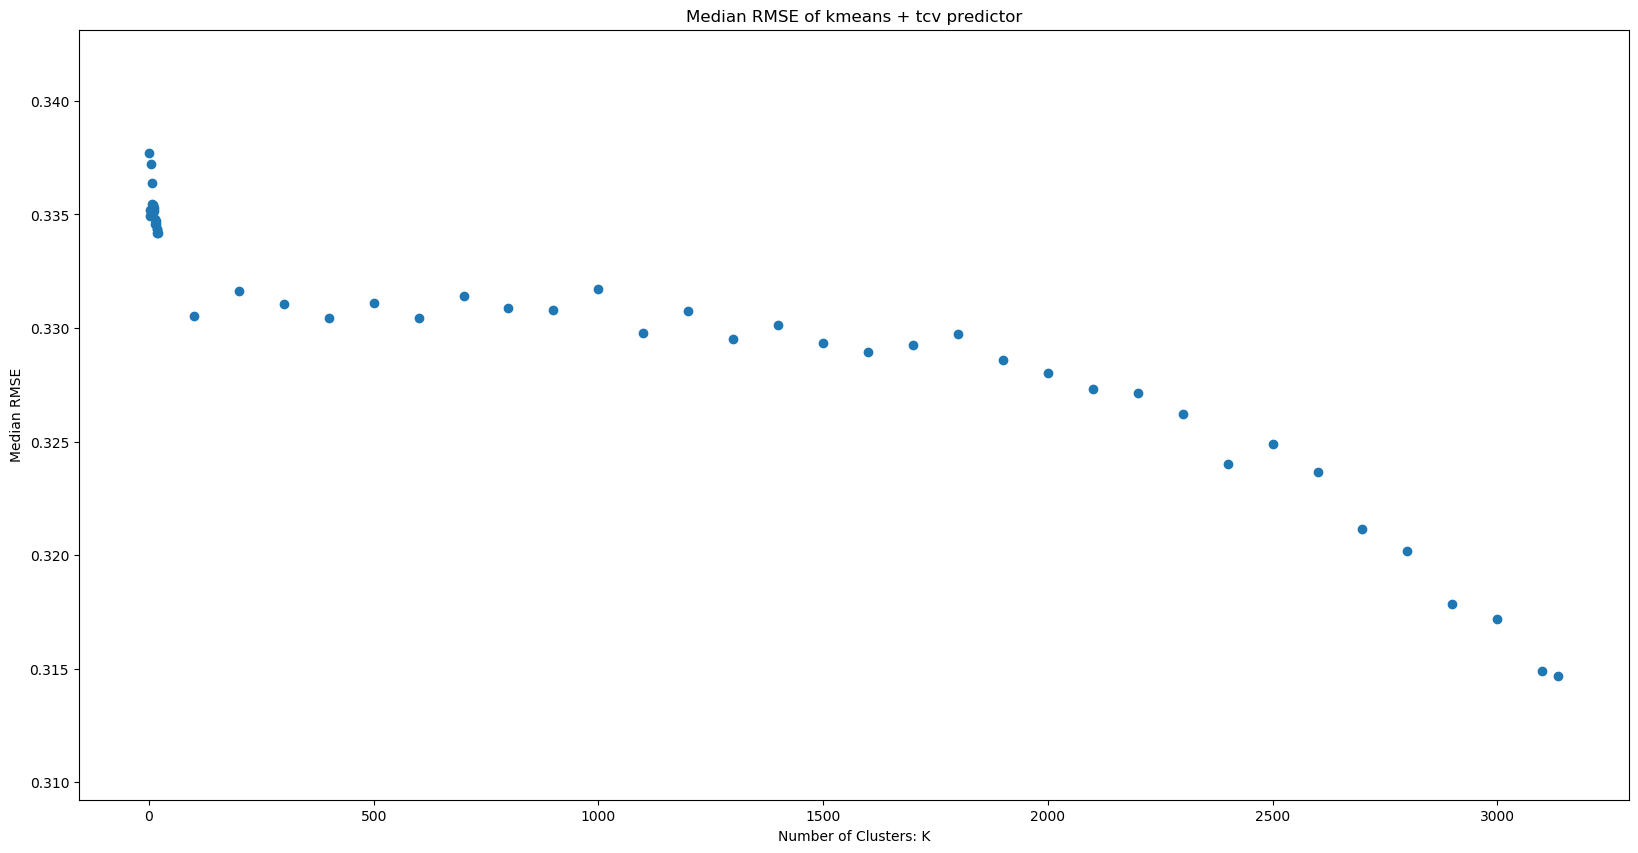

In [91]:
plt.figure(figsize=(20,10))
plt.scatter(medians_df["K"], medians_df["Chosen_by_rmse_RMSE"])
plt.xlabel("Number of Clusters: K")
plt.ylabel("Median RMSE")
plt.title("Median RMSE of kmeans + tcv predictor")
plt.show()

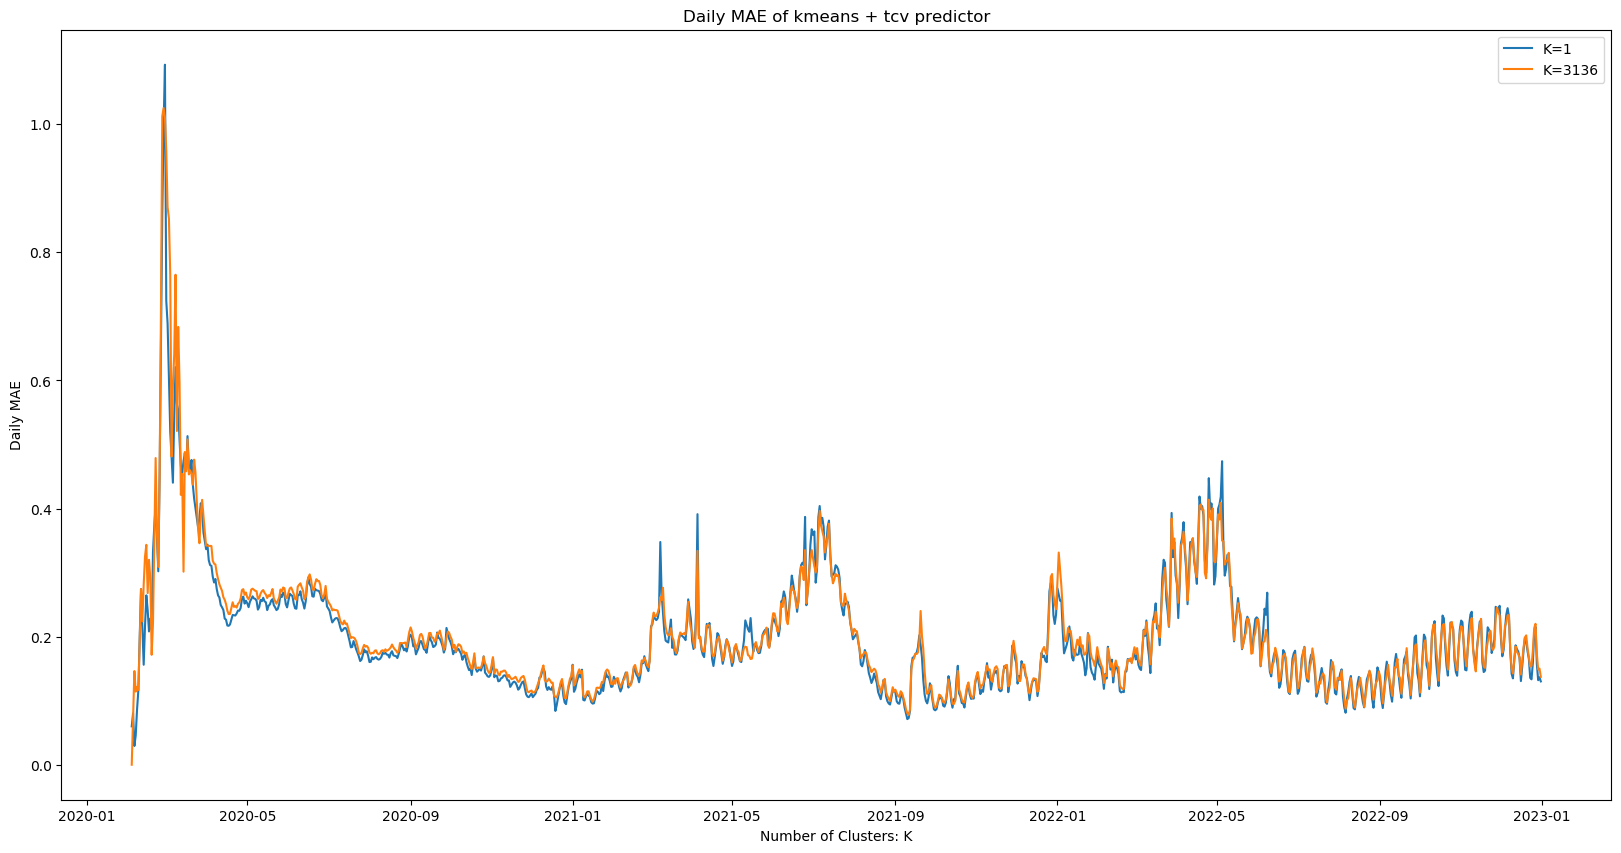

In [96]:
plt.figure(figsize=(20,10))
plt.plot(daily_metrics_dfs[1]["Chosen_by_mae_MAE"], label="K=1")
plt.plot(daily_metrics_dfs[3136]["Chosen_by_mae_MAE"], label="K=3136")
plt.xlabel("Number of Clusters: K")
plt.ylabel("Daily MAE")
plt.title("Daily MAE of kmeans + tcv predictor")
plt.legend()
plt.show()

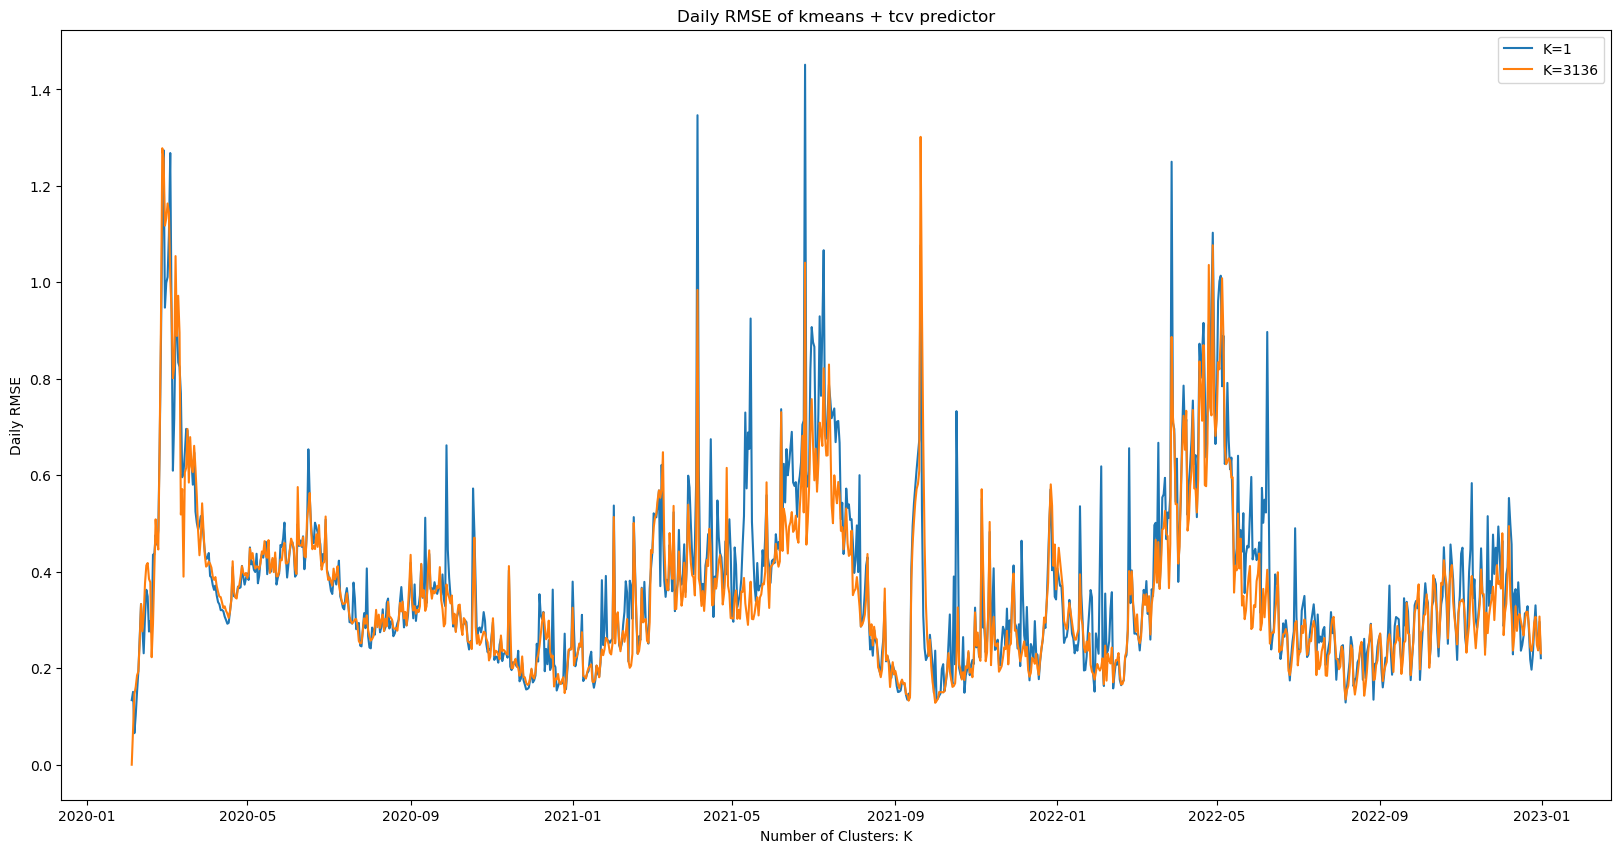

In [95]:
plt.figure(figsize=(20,10))
plt.plot(daily_metrics_dfs[1]["Chosen_by_rmse_RMSE"], label="K=1")
plt.plot(daily_metrics_dfs[3136]["Chosen_by_rmse_RMSE"], label="K=3136")
plt.xlabel("Number of Clusters: K")
plt.ylabel("Daily RMSE")
plt.title("Daily RMSE of kmeans + tcv predictor")
plt.legend()
plt.show()

In [71]:
test_df.index = test_df["date_query"]

In [72]:
test_df

,date_query,Chosen_by_mae_MAE,Chosen_by_mae_RMSE,Chosen_by_rmse_MAE,Chosen_by_rmse_RMSE
date_query,,,,,
2020-02-04,2020-02-04,4.973799e-14,4.973799e-14,4.973799e-14,4.973799e-14
2020-02-05,2020-02-05,7.045166e-02,7.045166e-02,7.045166e-02,7.045166e-02
2020-02-06,2020-02-06,1.462455e-01,1.462455e-01,1.462455e-01,1.462455e-01
2020-02-07,2020-02-07,1.141293e-01,1.614032e-01,1.141293e-01,1.614032e-01
2020-02-08,2020-02-08,1.215941e-01,1.853807e-01,1.215941e-01,1.853807e-01
...,...,...,...,...,...
2023-01-03,2023-01-03,NaN,NaN,NaN,NaN
2023-01-04,2023-01-04,NaN,NaN,NaN,NaN
2023-01-05,2023-01-05,NaN,NaN,NaN,NaN


In [97]:
col_names = ["K"] + list(daily_metrics_dfs[1].columns)
old_medians_df = pd.DataFrame(columns=col_names)
for K in K_list:
    old_daily_metrics = daily_metrics_dfs[K]
    old_daily_metrics = old_daily_metrics[old_daily_metrics.index <= "2021-09-12"]
    old_row = [K] + list(old_daily_metrics.median())
    old_medians_df = old_medians_df.append(pd.Series(old_row, index=medians_df.columns), ignore_index=True)


In [98]:
old_medians_df

,K,Chosen_by_mae_MAE,Chosen_by_mae_RMSE,Chosen_by_rmse_MAE,Chosen_by_rmse_RMSE
0,1.0,0.190285,0.367413,0.195870,0.367413
1,2.0,0.187617,0.364658,0.195129,0.365663
2,3.0,0.187558,0.366104,0.195042,0.366008
3,4.0,0.187558,0.366104,0.194386,0.366007
4,5.0,0.187617,0.366539,0.192912,0.367931
5,6.0,0.187560,0.366997,0.193508,0.366088
6,7.0,0.187558,0.366104,0.193569,0.366430
7,8.0,0.190079,0.366909,0.193322,0.365776
8,9.0,0.190079,0.366909,0.193328,0.365776
9,10.0,0.188040,0.368354,0.193102,0.364512
